# SWYNEX Internship Task 2: Exploratory Data Analysis

## Exploratory Data Analysis of FMCG Retail Transactions

### Objective

The objective of this task is to perform Exploratory Data Analysis (EDA) on the cleaned FMCG retail transaction dataset to identify important statistics, trends, patterns, and anomalies using Python and Pandas.

### Dataset

The dataset contains retail transaction records with information about:

- Customer details
- Country
- Product category
- Unit price
- Quantity
- Transaction date
- Payment method
- Revenue

### Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_fmcg_dataset.csv to cleaned_fmcg_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_fmcg_dataset.csv")

In [ ]:
df.shape

(1480, 11)

In [ ]:
df.head()

,transaction_id,customer_name,email,age,country,product_category,unit_price,quantity,transaction_date,payment_method,revenue
0,ORD100000,Patricia Gardner,NaN,66,Nigeria,Groceries,499.99,3.0,2024-04-16,Cash,1499.97
1,ORD100002,Richard Carter,qdiaz@perez-booker.com,59,Nigeria,Electronics,499.99,3.0,2024-04-27,Card,1499.97
2,ORD100003,Scott Underwood,donna50@gmail.com,51,United States,Electronics,1500.00,3.0,2024-10-14,Card,4500.00
3,ORD100004,Shawn Castro,betty24@jones-russell.com,23,Nigeria,Groceries,500.00,2.0,2024-04-16,Cash,1000.00
4,ORD100005,James Castillo,vmay@hotmail.com,48,Nigeria,Groceries,500.00,4.0,2025-02-09,Card,2000.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    1480 non-null   object 
 1   customer_name     1480 non-null   object 
 2   email             1359 non-null   object 
 3   age               1480 non-null   int64  
 4   country           1480 non-null   object 
 5   product_category  1480 non-null   object 
 6   unit_price        1480 non-null   float64
 7   quantity          1480 non-null   float64
 8   transaction_date  1480 non-null   object 
 9   payment_method    1480 non-null   object 
 10  revenue           1480 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 127.3+ KB


In [ ]:
df.describe()

,age,unit_price,quantity,revenue
count,1480.000000,1480.000000,1480.000000,1480.000000
mean,43.831757,1130.919622,2.470270,2761.937108
std,14.376120,663.022895,1.371173,2364.061589
min,18.000000,499.990000,1.000000,499.990000
25%,33.000000,500.000000,1.000000,1133.520000
50%,44.000000,1133.520000,2.000000,2267.040000
75%,56.000000,1500.000000,3.000000,3600.000000
max,69.000000,2500.000000,5.000000,12500.000000


In [ ]:
print("PRODUCT CATEGORY")
print(df["product_category"].value_counts())

print("\nCOUNTRY")
print(df["country"].value_counts())

print("\nPAYMENT METHOD")
print(df["payment_method"].value_counts())

PRODUCT CATEGORY
product_category
Electronics    615
Groceries      372
Fashion        285
Home           208
Name: count, dtype: int64

COUNTRY
country
Nigeria           535
United States     428
Ghana             217
United Kingdom    163
Turkey            137
Name: count, dtype: int64

PAYMENT METHOD
payment_method
Card        803
Cash        357
Transfer    320
Name: count, dtype: int64


In [ ]:
category_revenue = df.groupby("product_category")["revenue"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

category_revenue

,sum,mean,count
product_category,,,
Electronics,1733594.72,2818.853203,615
Groceries,984612.96,2646.809032,372
Fashion,797580.21,2798.527053,285
Home,571879.03,2749.418413,208


In [ ]:
country_revenue = df.groupby("country")["revenue"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

country_revenue

,sum,mean,count
country,,,
Nigeria,1475058.34,2757.118393,535
United States,1173956.64,2742.889346,428
Ghana,577942.35,2663.328802,217
United Kingdom,487940.40,2993.499387,163
Turkey,372769.19,2720.942993,137


In [ ]:
payment_revenue = df.groupby("payment_method")["revenue"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

payment_revenue

,sum,mean,count
payment_method,,,
Card,2295070.96,2858.120747,803
Cash,954148.44,2672.684706,357
Transfer,838447.52,2620.148500,320


In [ ]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [ ]:
df["transaction_date"].dtype

dtype('<M8[ns]')

In [ ]:
monthly_revenue = (
    df.groupby(df["transaction_date"].dt.to_period("M"))["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["transaction_date"] = monthly_revenue["transaction_date"].astype(str)

monthly_revenue

,transaction_date,revenue
0,2024-02,88633.89
1,2024-03,164272.02
2,2024-04,173436.03
3,2024-05,126836.27
4,2024-06,159335.63
5,2024-07,230471.00
6,2024-08,179602.31
7,2024-09,198201.56
8,2024-10,182602.07
9,2024-11,142972.33


In [ ]:
monthly_transactions = (
    df.groupby(df["transaction_date"].dt.to_period("M"))
    .size()
    .reset_index(name="transaction_count")
)

monthly_transactions["transaction_date"] = (
    monthly_transactions["transaction_date"].astype(str)
)

monthly_transactions

,transaction_date,transaction_count
0,2024-02,32
1,2024-03,61
2,2024-04,64
3,2024-05,53
4,2024-06,62
5,2024-07,83
6,2024-08,66
7,2024-09,66
8,2024-10,59
9,2024-11,64


In [ ]:
payment_revenue = df.groupby("payment_method")["revenue"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

payment_revenue

,sum,mean,count
payment_method,,,
Card,2295070.96,2858.120747,803
Cash,954148.44,2672.684706,357
Transfer,838447.52,2620.148500,320


In [ ]:
quantity_revenue = df.groupby("quantity")["revenue"].agg(
    ["sum", "mean", "count"]
).sort_index()

quantity_revenue

,sum,mean,count
quantity,,,
1.0,543208.77,1158.227655,469
2.0,891415.84,2262.476751,394
3.0,859016.22,3329.520233,258
4.0,794007.84,4670.634353,170
5.0,1000018.25,5291.101852,189


In [ ]:
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["revenue"] < lower_bound) |
    (df["revenue"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 1133.52
Q3: 3600.0
IQR: 2466.48
Lower Bound: -2566.2000000000003
Upper Bound: 7299.72
Number of outliers: 105


In [ ]:
outliers.sort_values("revenue", ascending=False)[
    ["transaction_id", "product_category", "country",
     "quantity", "unit_price", "revenue"]
].head(10)

,transaction_id,product_category,country,quantity,unit_price,revenue
28,ORD100033,Electronics,Ghana,5.0,2500.0,12500.0
65,ORD100080,Home,United States,5.0,2500.0,12500.0
463,ORD100577,Electronics,Nigeria,5.0,2500.0,12500.0
492,ORD100612,Electronics,United Kingdom,5.0,2500.0,12500.0
419,ORD100520,Electronics,United States,5.0,2500.0,12500.0
426,ORD100528,Electronics,Nigeria,5.0,2500.0,12500.0
238,ORD100288,Electronics,Nigeria,5.0,2500.0,12500.0
211,ORD100249,Home,Ghana,5.0,2500.0,12500.0
606,ORD100746,Fashion,United States,5.0,2500.0,12500.0
1049,ORD101283,Fashion,Turkey,5.0,2500.0,12500.0


In [ ]:
price_revenue = df.groupby("unit_price")["revenue"].agg(
    ["sum", "mean", "count"]
).sort_index()

price_revenue

,sum,mean,count
unit_price,,,
499.99,265994.68,1231.456852,216
500.00,493000.00,1277.202073,386
1133.52,438672.24,2741.701500,160
1200.00,870000.00,2979.452055,292
1500.00,817500.00,3649.553571,224
2500.00,1202500.00,5952.970297,202


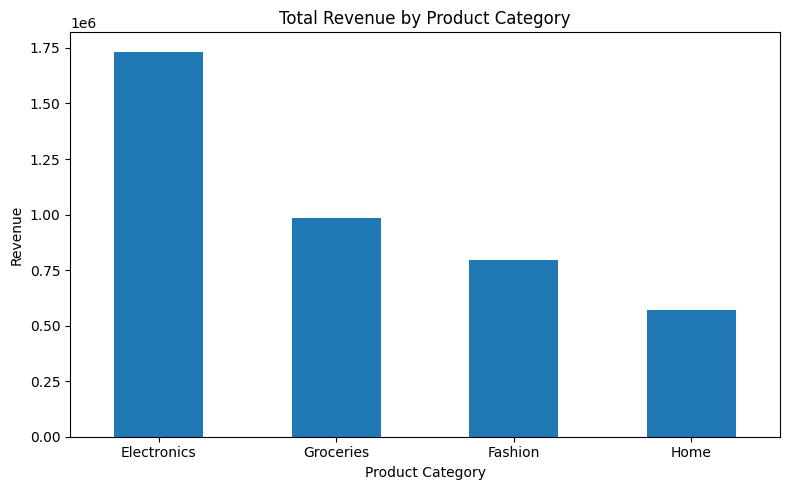

In [ ]:
import matplotlib.pyplot as plt

category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

category_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

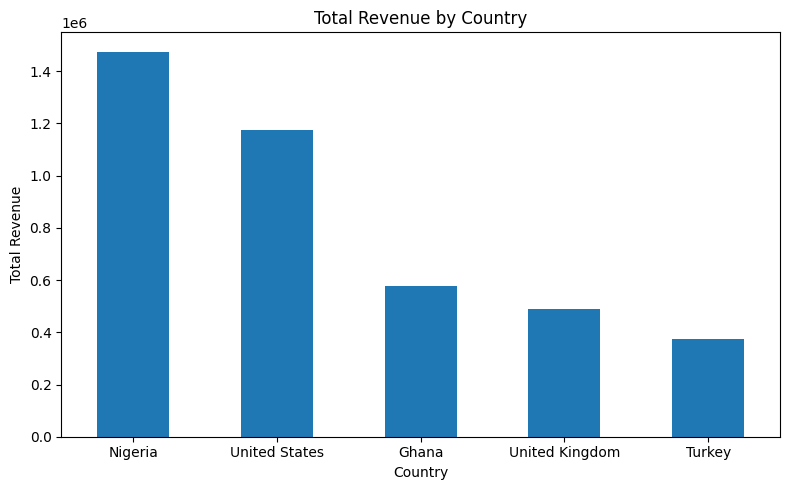

In [ ]:
country_revenue = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
country_revenue.plot(kind="bar")

plt.title("Total Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

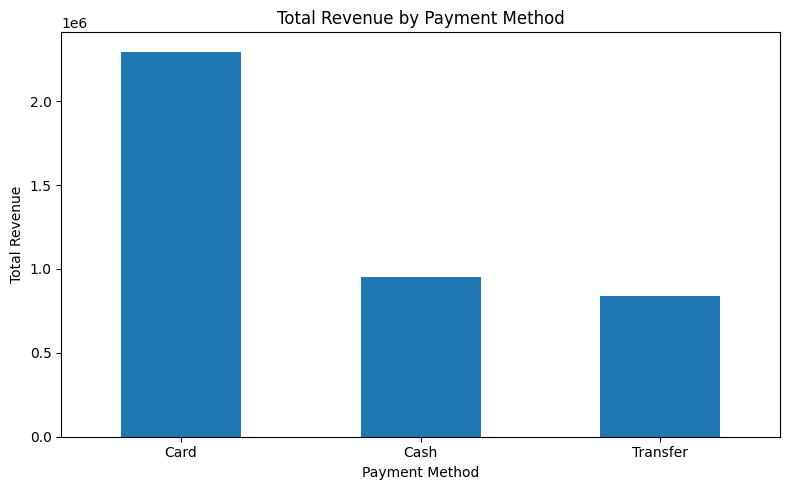

In [ ]:
payment_revenue = df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_revenue.plot(kind="bar")

plt.title("Total Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

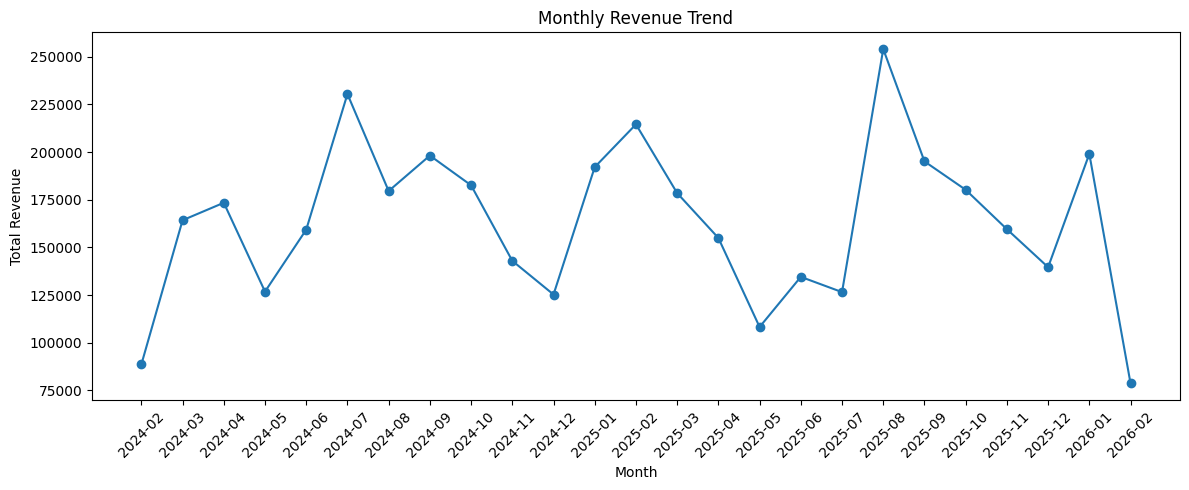

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["transaction_date"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

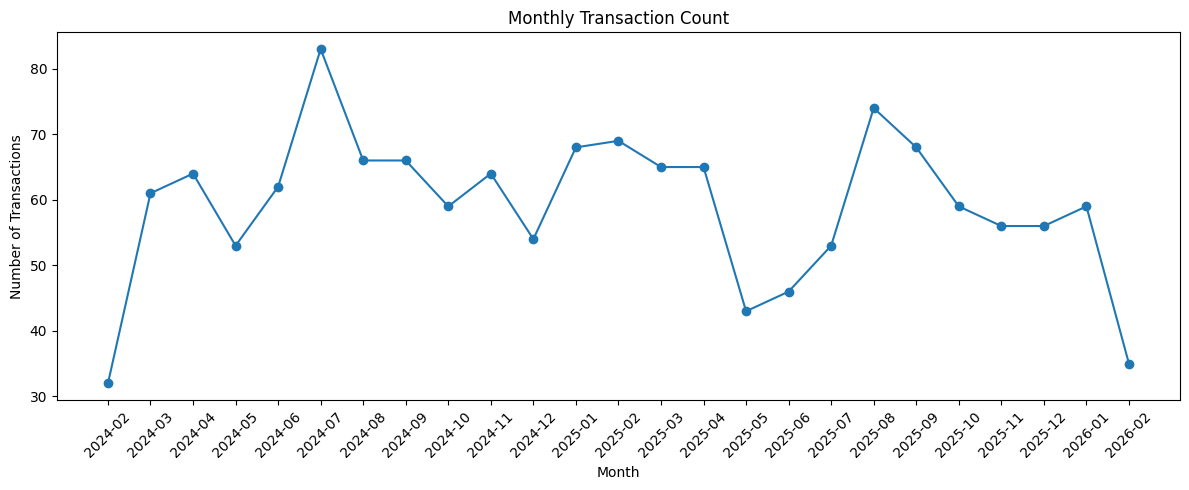

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_transactions["transaction_date"],
    monthly_transactions["transaction_count"],
    marker="o"
)

plt.title("Monthly Transaction Count")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

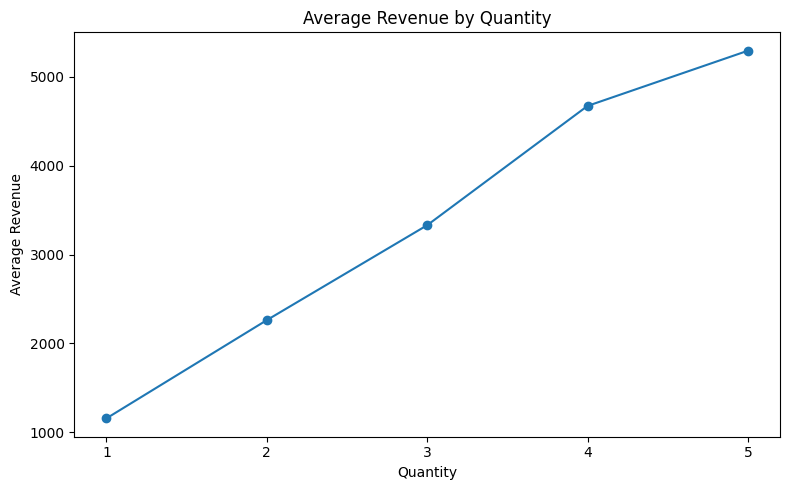

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    quantity_revenue.index,
    quantity_revenue["mean"],
    marker="o"
)

plt.title("Average Revenue by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Average Revenue")
plt.xticks(quantity_revenue.index)
plt.tight_layout()
plt.show()

## Key Insights

1. **Electronics generated the highest total revenue** among the product categories, with ₹17,33,594.72 from 615 transactions.

2. **Nigeria recorded the highest total revenue** among the countries, with ₹14,75,058.34 from 535 transactions. The United Kingdom had the highest average revenue per transaction at ₹2,993.50.

3. **Card payments contributed the highest total revenue**, generating ₹22,95,070.96 across 803 transactions.

4. **Revenue increased with transaction quantity.** Average revenue rose from ₹1,158.23 for quantity 1 to ₹5,291.10 for quantity 5.

5. **Higher unit prices were associated with higher average transaction revenue.** The ₹2,500 unit-price group had the highest average revenue of ₹5,952.97.

6. **Revenue varied considerably across months.** The highest monthly revenue was recorded in August 2025 at ₹2,54,070.12, while February 2026 recorded ₹78,702.09. February 2026 may represent a partial month and should therefore be interpreted cautiously.

7. **105 transactions were identified as high-revenue outliers** using the IQR method, with revenue above ₹7,299.72. The highest observed revenue was ₹12,500, resulting from transactions with a quantity of 5 and a unit price of ₹2,500.

## Conclusion

The exploratory data analysis provided an overview of transaction patterns, revenue distribution, customer activity, payment methods, product categories, countries, and monthly trends.

The analysis showed that Electronics generated the highest total revenue, Nigeria recorded the highest country-level revenue, and Card was the most frequently used payment method as well as the largest contributor to total revenue. Higher quantities and higher unit prices were associated with higher average transaction revenue.

The outlier analysis identified 105 high-revenue transactions. These were retained because the observed values were consistent with combinations of higher quantities and unit prices rather than clearly invalid records.

Overall, the EDA helped identify important patterns and relationships in the cleaned retail transaction dataset and provided a foundation for further data-driven analysis.